# 📊 Exploration du dataset IMDB

## 🎯 Objectif
Analyser et comprendre la structure du jeu de données **IMDB** (50 000 critiques de films) avant de construire un modèle de classification binaire (positif / négatif).

## 📁 Description des données
- **Source** : HuggingFace Datasets (`imdb`)
- **Taille** : 50 000 critiques équilibrées (25k train / 25k test)
- **Labels** : `0` = négatif, `1` = positif
- **Langue** : Anglais
- **Contenu** : Critiques brutes avec balises HTML (`<br />`)

## 📋 Plan du notebook
1. Importation des librairies et chargement des données
2. Visualisation de la distribution des classes
3. Analyse de la longueur des textes (mots par critique)
4. Résumé et conclusions

## 📚 Table des matières
- [Importation](#importation)
- [Exemples de textes](#exemples-de-textes)
- [Distribution des classes](#distribution-des-classes)
- [Longueur des textes](#longueur-des-textes)
- [Résumé final](#résumé-final)

# Importation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des CSV locaux
train_df = pd.read_csv("data/imdb_train.csv")
test_df  = pd.read_csv("data/imdb_test.csv")

print(f"Train : {len(train_df):,} exemples")
print(f"Test  : {len(test_df):,} exemples")
print(f"Colonnes : {list(train_df.columns)}")

Train : 25,000 exemples
Test  : 25,000 exemples
Colonnes : ['text', 'label']


# Exemples de textes

In [2]:
print("=== EXEMPLE POSITIF (label=1) ===")
print(train_df[train_df["label"]==1].iloc[0]["text"][:400])
print()
print("=== EXEMPLE NÉGATIF (label=0) ===")
print(train_df[train_df["label"]==0].iloc[0]["text"][:400])

=== EXEMPLE POSITIF (label=1) ===
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-

=== EXEMPLE NÉGATIF (label=0) ===
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student name


# Distribution des classes

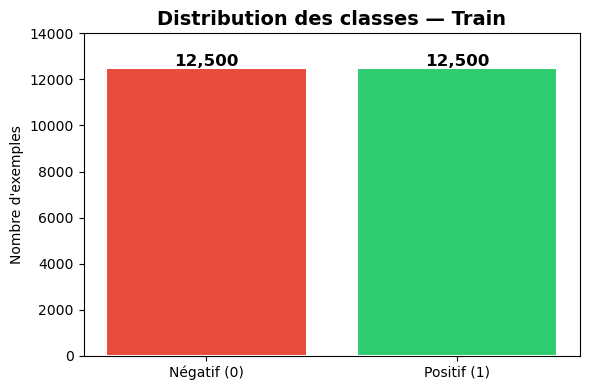

✅ Dataset parfaitement équilibré : 50% / 50%


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = train_df["label"].value_counts().sort_index()
bars = ax.bar(["Négatif (0)", "Positif (1)"], counts.values,
              color=["#e74c3c", "#2ecc71"], edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f"{val:,}", ha="center", fontweight="bold", fontsize=12)

ax.set_title("Distribution des classes — Train", fontweight="bold", fontsize=14)
ax.set_ylabel("Nombre d'exemples")
ax.set_ylim(0, 14000)
plt.tight_layout()
plt.savefig("data/class_distribution.png")
plt.show()

print("✅ Dataset parfaitement équilibré : 50% / 50%")

# Longueur des textes 

=== STATISTIQUES DE LONGUEUR ===
Moyenne  : 234 mots
Médiane  : 174 mots
Min      : 10 mots
Max      : 2,470 mots
Quantile 95% : 598 mots


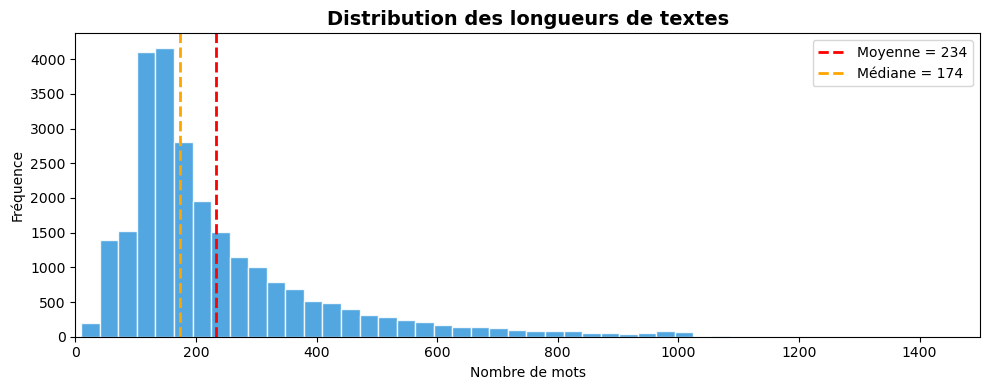

In [5]:
# Calcul du nombre de mots par texte
train_df["nb_mots"] = train_df["text"].apply(lambda x: len(x.split()))

print("=== STATISTIQUES DE LONGUEUR ===")
print(f"Moyenne  : {train_df['nb_mots'].mean():.0f} mots")
print(f"Médiane  : {train_df['nb_mots'].median():.0f} mots")
print(f"Min      : {train_df['nb_mots'].min()} mots")
print(f"Max      : {train_df['nb_mots'].max():,} mots")
print(f"Quantile 95% : {train_df['nb_mots'].quantile(0.95):.0f} mots")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df["nb_mots"], bins=80, color="#3498db", edgecolor="white", alpha=0.85)
ax.axvline(train_df["nb_mots"].mean(),   color="red",    linestyle="--",
           linewidth=2, label=f"Moyenne = {train_df['nb_mots'].mean():.0f}")
ax.axvline(train_df["nb_mots"].median(), color="orange", linestyle="--",
           linewidth=2, label=f"Médiane = {train_df['nb_mots'].median():.0f}")
ax.set_xlim(0, 1500)
ax.set_title("Distribution des longueurs de textes", fontweight="bold", fontsize=14)
ax.set_xlabel("Nombre de mots")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.savefig("data/text_length.png")
plt.show()

## 🔍 Interprétation des résultats
- **Équilibrage parfait** : 50% positifs / 50% négatifs → pas de biais de classe
- **Longueur moyenne** : ~234 mots, médiane à 174 mots → distribution asymétrique vers la droite
- **Textes longs** : certains dépassent 2 400 mots → nécessite une gestion (troncature ou attention)
- **Présence de balises HTML** (`<br />`) → à nettoyer lors du prétraitement

✅ L'exploration est terminée. Prochaine étape : prétraitement des textes.

# Résumé final

In [6]:
print("╔══════════════════════════════════════════════╗")
print("║        RÉSUMÉ — ÉTAPE 1 : EXPLORATION        ║")
print("╠══════════════════════════════════════════════╣")
print("║  Source        : HuggingFace — imdb          ║")
print("║  Tâche         : Classification binaire      ║")
print(f"║  Train         : {len(train_df):,} exemples              ║")
print(f"║  Test          : {len(test_df):,} exemples              ║")
print("║  Classes       : 0=Négatif  /  1=Positif    ║")
print("║  Équilibré     : Oui (50% / 50%)             ║")
print(f"║  Moy. mots     : {train_df['nb_mots'].mean():.0f} mots                  ║")
print(f"║  Médiane mots  : {train_df['nb_mots'].median():.0f} mots                  ║")
print("╚══════════════════════════════════════════════╝")
print()
print("✅ Étape 1 terminée ! Dis 'étape 2' pour continuer.")

╔══════════════════════════════════════════════╗
║        RÉSUMÉ — ÉTAPE 1 : EXPLORATION        ║
╠══════════════════════════════════════════════╣
║  Source        : HuggingFace — imdb          ║
║  Tâche         : Classification binaire      ║
║  Train         : 25,000 exemples              ║
║  Test          : 25,000 exemples              ║
║  Classes       : 0=Négatif  /  1=Positif    ║
║  Équilibré     : Oui (50% / 50%)             ║
║  Moy. mots     : 234 mots                  ║
║  Médiane mots  : 174 mots                  ║
╚══════════════════════════════════════════════╝

✅ Étape 1 terminée ! Dis 'étape 2' pour continuer.


> 📌 *Suite de l'étape 1 (exploration) — Passage à la modélisation après prétraitement*